In [1]:
# ============================
# F5 — Week 04: BO update (MAXIMISE)
# Structure: Config → Load → Surrogate → Acquisition → Diagnostics → Output
# ============================

# ----------------------------
# Imports (keep all at top)
# ----------------------------
import os
import warnings
import numpy as np
import matplotlib.pyplot as plt

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel as C
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# ----------------------------
# 0) Config
# ----------------------------
# Your project paths (as requested)
INPUTS_PATH = "data/F5/initial_inputs.npy"
OUTPUTS_PATH = "data/F5/initial_outputs.npy"

# Fallback to local uploaded paths if the relative ones don't exist (handy in Colab / sandbox)
FALLBACK_INPUTS_PATH = "/mnt/data/initial_inputs.npy"
FALLBACK_OUTPUTS_PATH = "/mnt/data/initial_outputs.npy"

BOUNDS = np.array([[0.0, 1.0]] * 4)  # 4D, each in [0,1]
MAXIMIZE = True

# Acquisition / search controls (Week 04: more exploitation + tighter local search)
N_CANDIDATES = 80000
LOCAL_STD = 0.02         # tighter micro-refinement than week 03
LOCAL_FRAC = 0.85        # mostly local, small global sprinkle
KAPPA = 0.30             # lower exploration than week 03
BATCH_SIZE = 5
MIN_DIST = 0.02          # avoid near-duplicate suggestions in batch

RANDOM_SEED = 0

# Optional domain-informed filter (based on week03 interpretation)
USE_DOMAIN_FILTER = True
DOMAIN_FILTER = {
    "x1_max": 0.55,   # prefer lower x1
    "x2_min": 0.65,   # moderate-high x2
    "x3_min": 0.75,   # high x3
    "x4_min": 0.75,   # high x4
}

In [3]:
# ----------------------------
# 1) Load Data
# ----------------------------
def resolve_path(primary: str, fallback: str) -> str:
    return primary if os.path.exists(primary) else fallback

X_path = resolve_path(INPUTS_PATH, FALLBACK_INPUTS_PATH)
y_path = resolve_path(OUTPUTS_PATH, FALLBACK_OUTPUTS_PATH)

X = np.load(X_path)
y = np.load(y_path)

assert X.ndim == 2 and X.shape[1] == 4, f"Expected X shape (n,4), got {X.shape}"
assert y.ndim == 1 and len(y) == len(X), f"Expected y shape (n,), got {y.shape}"

best_idx_raw = int(np.argmax(y))
print("Loaded:")
print(" - X:", X.shape, "from", X_path)
print(" - y:", y.shape, "from", y_path)
print("\nBest observed y:", float(y[best_idx_raw]))
print("At X:", X[best_idx_raw])

Loaded:
 - X: (22, 4) from data/F5/initial_inputs.npy
 - y: (22,) from data/F5/initial_outputs.npy

Best observed y: 3240.0066354498244
At X: [0.236344 0.904546 0.999999 0.988293]


In [4]:
# ----------------------------
# 2) Surrogate
# ----------------------------
# Stabilise extreme output range
y_t = np.log1p(y)  # log(1+y)

# GP: Constant * Matern(ν=2.5) with ARD lengthscales
kernel = C(1.0, (1e-3, 1e3)) * Matern(
    length_scale=np.ones(X.shape[1]),
    length_scale_bounds=(1e-2, 1e2),
    nu=2.5
)

# Small nugget for numerical stability
gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-6,
    normalize_y=True,
    n_restarts_optimizer=10,
    random_state=RANDOM_SEED
)

# Sometimes sklearn warns about hitting bounds; not usually harmful here
warnings.filterwarnings("ignore", category=UserWarning)

gp.fit(X, y_t)
print("\nFitted GP kernel:", gp.kernel_)


Fitted GP kernel: 2.41**2 * Matern(length_scale=[2.11, 0.605, 1.36, 0.806], nu=2.5)


In [5]:
# ----------------------------
# 3) Acquisition
# ----------------------------
rng = np.random.default_rng(RANDOM_SEED)

best_idx = int(np.argmax(y_t))
x_best = X[best_idx].copy()

n_local = int(N_CANDIDATES * LOCAL_FRAC)
n_global = N_CANDIDATES - n_local

cand_local = x_best + rng.normal(0.0, LOCAL_STD, size=(n_local, X.shape[1]))
cand_local = np.clip(cand_local, BOUNDS[:, 0], BOUNDS[:, 1])

cand_global = rng.uniform(BOUNDS[:, 0], BOUNDS[:, 1], size=(n_global, X.shape[1]))

candidates = np.vstack([cand_local, cand_global])

if USE_DOMAIN_FILTER:
    m = (
        (candidates[:, 0] <= DOMAIN_FILTER["x1_max"]) &
        (candidates[:, 1] >= DOMAIN_FILTER["x2_min"]) &
        (candidates[:, 2] >= DOMAIN_FILTER["x3_min"]) &
        (candidates[:, 3] >= DOMAIN_FILTER["x4_min"])
    )
    candidates = candidates[m]

mu_c, std_c = gp.predict(candidates, return_std=True)
ucb = mu_c + KAPPA * std_c  # maximise in transformed space

# Greedy diverse batch selection
order = np.argsort(-ucb)
selected = []
for idx in order:
    x = candidates[idx]
    if len(selected) == 0:
        selected.append(x)
    else:
        d = np.linalg.norm(np.array(selected) - x, axis=1)
        if np.all(d >= MIN_DIST):
            selected.append(x)
    if len(selected) >= BATCH_SIZE:
        break

X_next_batch = np.array(selected)



Diagnostics (train, log1p scale):
 - RMSE: 3.88713e-06
 - R2:   1


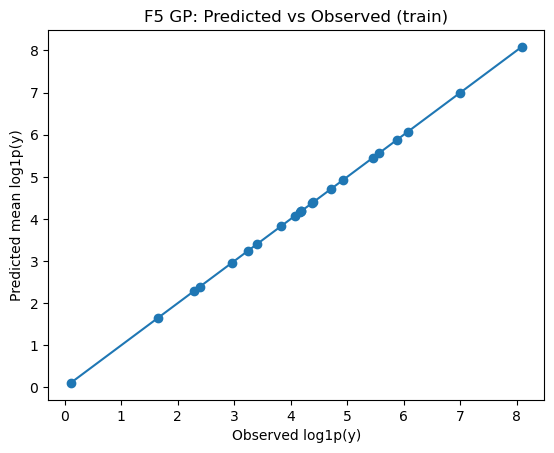

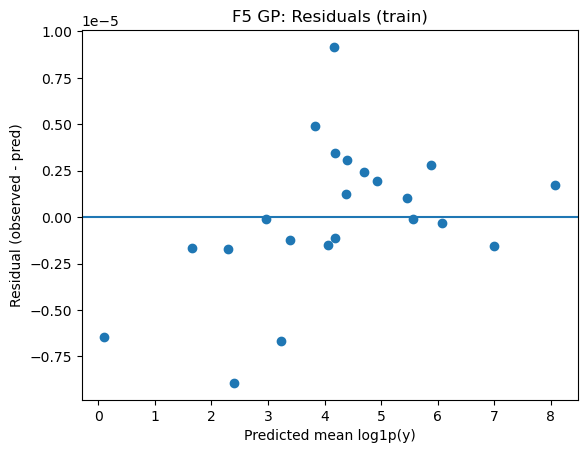


ARD lengthscales (smaller => more sensitive):
 - x1: 2.1077
 - x2: 0.6055
 - x3: 1.3562
 - x4: 0.8059


In [6]:
# ----------------------------
# 4) Diagnostics
# ----------------------------
mu_train, std_train = gp.predict(X, return_std=True)

rmse = np.sqrt(mean_squared_error(y_t, mu_train))
r2 = r2_score(y_t, mu_train)

print("\nDiagnostics (train, log1p scale):")
print(f" - RMSE: {rmse:.6g}")
print(f" - R2:   {r2:.6g}")

# Predicted vs observed (transformed)
plt.figure()
plt.scatter(y_t, mu_train)
mn = float(min(y_t.min(), mu_train.min()))
mx = float(max(y_t.max(), mu_train.max()))
plt.plot([mn, mx], [mn, mx])
plt.xlabel("Observed log1p(y)")
plt.ylabel("Predicted mean log1p(y)")
plt.title("F5 GP: Predicted vs Observed (train)")
plt.show()

# Residuals
resid = (y_t - mu_train)
plt.figure()
plt.scatter(mu_train, resid)
plt.axhline(0.0)
plt.xlabel("Predicted mean log1p(y)")
plt.ylabel("Residual (observed - pred)")
plt.title("F5 GP: Residuals (train)")
plt.show()

# Feature relevance proxy: ARD lengthscales (smaller = more sensitive)
try:
    lengthscales = gp.kernel_.k2.length_scale  # Constant * Matern -> .k2 is Matern
    print("\nARD lengthscales (smaller => more sensitive):")
    for i, ls in enumerate(np.atleast_1d(lengthscales), start=1):
        print(f" - x{i}: {float(ls):.4f}")
except Exception:
    pass



In [7]:
# ----------------------------
# 5) Output (what to submit)
# ----------------------------
np.set_printoptions(precision=6, suppress=True)

print("\nSuggested NEXT batch (submit if allowed):")
print(X_next_batch)

print("\nSingle best NEXT point (submit this ONE row if required):")
print(X_next_batch[0])

# Context only (NOT for submission): predicted yield on original scale
pred_log, pred_std = gp.predict(X_next_batch[:1], return_std=True)
pred_y = np.expm1(pred_log)
print("\nModel context only (NOT for submission):")
print("Predicted mean y:", float(pred_y[0]), "| Predicted std (log-scale):", float(pred_std[0]))


Suggested NEXT batch (submit if allowed):
[[0.175225 0.851189 1.       1.      ]
 [0.19423  0.838888 1.       1.      ]
 [0.223604 0.839037 1.       1.      ]
 [0.19397  0.860917 1.       1.      ]
 [0.23882  0.824864 1.       0.999119]]

Single best NEXT point (submit this ONE row if required):
[0.175225 0.851189 1.       1.      ]

Model context only (NOT for submission):
Predicted mean y: 3585.0126882266254 | Predicted std (log-scale): 0.39014111166331866
